In [2]:
import sys, os, json, time
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)

from io_utils import DATA_PROCESSED, MODELS, REPORTS, load_json, save_json
from model import build_ann_model
from model_v2 import EXPERIMENTS_V2

np.random.seed(42); tf.random.set_seed(42)
sns.set_theme(style='whitegrid')

In [3]:
selected_features = load_json('selected_features_v2.json')
label_names = {int(k): v for k, v in load_json('label_names_v2.json').items()}

# Class weight DIMUAT dari file (dihitung sekali di 02b), TIDAK dihitung ulang
class_weight_dict = {int(k): v for k, v in load_json('class_weight_v2.json').items()}

train_df       = pd.read_parquet(os.path.join(DATA_PROCESSED, 'train_v2.parquet'))
train_smote_df = pd.read_parquet(os.path.join(DATA_PROCESSED, 'train_v2_smote.parquet'))
val_df         = pd.read_parquet(os.path.join(DATA_PROCESSED, 'val_v2.parquet'))
test_df        = pd.read_parquet(os.path.join(DATA_PROCESSED, 'test_v2.parquet'))

X_train, y_train             = train_df[selected_features].values,       train_df['risk_class'].values
X_train_smote, y_train_smote = train_smote_df[selected_features].values, train_smote_df['risk_class'].values
X_val, y_val                 = val_df[selected_features].values,         val_df['risk_class'].values
X_test, y_test               = test_df[selected_features].values,        test_df['risk_class'].values

input_dim = X_train.shape[1]
n_classes = len(label_names)

print(f'Train asli  : {X_train.shape}')
print(f'Train SMOTE : {X_train_smote.shape}  (dipakai khusus E7)')
print(f'Val: {X_val.shape} | Test: {X_test.shape}')
print('Class weight (dimuat dari class_weight_v2.json):', class_weight_dict)

Train asli  : (621165, 34)
Train SMOTE : (744831, 34)  (dipakai khusus E7)
Val: (133107, 34) | Test: (133107, 34)
Class weight (dimuat dari class_weight_v2.json): {0: 1.4104756195588495, 1: 0.484716750123488, 2: 4.386758474576271}


In [4]:
def run_experiment_v2(exp_id, config, epochs=100, batch_size=256, verbose=2):
    """Melatih & mengevaluasi satu skenario eksperimen v2 (E1..E7)."""
    model = build_ann_model(
        input_dim=input_dim,
        n_classes=n_classes,
        use_dropout=config['use_dropout'],
        use_batchnorm=config['use_batchnorm'],
        name=f'ann_v2_{exp_id.lower()}',
    )

    # E7 pakai data hasil SMOTE, eksperimen lain pakai data asli
    if config.get('use_smote'):
        Xtr, ytr = X_train_smote, y_train_smote
    else:
        Xtr, ytr = X_train, y_train

    callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

    fit_kwargs = dict(
        x=Xtr, y=ytr,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch_size,
        callbacks=callbacks, verbose=verbose,
    )
    # Class weight HANYA untuk E5/E6 (jangan dobel dengan SMOTE di E7)
    if config['use_class_weight']:
        fit_kwargs['class_weight'] = class_weight_dict

    t0 = time.time()
    history = model.fit(**fit_kwargs)
    train_time = time.time() - t0

    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    result = {
        'exp_id': exp_id, 'description': config['description'],
        'accuracy': acc, 'precision_macro': p_macro, 'recall_macro': r_macro, 'f1_macro': f1_macro,
        'precision_weighted': p_w, 'recall_weighted': r_w, 'f1_weighted': f1_w,
        'epochs_trained': len(history.history['loss']), 'train_time_sec': train_time,
    }
    return model, history, y_pred, result

In [5]:
trained_models, histories, predictions, results = {}, {}, {}, []

for exp_id, config in EXPERIMENTS_V2.items():
    print(f'Menjalankan {exp_id}: {config["description"]} ...')
    model, history, y_pred, result = run_experiment_v2(exp_id, config)
    trained_models[exp_id] = model
    histories[exp_id] = history.history
    predictions[exp_id] = y_pred
    results.append(result)
    print(f'  -> accuracy={result["accuracy"]:.4f} | f1_macro={result["f1_macro"]:.4f} | '
          f'f1_weighted={result["f1_weighted"]:.4f} | epochs={result["epochs_trained"]}')

results_df = pd.DataFrame(results).set_index('exp_id')
results_df

Menjalankan E1: Baseline ANN (34 fitur) ...
Epoch 1/100
2427/2427 - 8s - 3ms/step - accuracy: 0.7409 - loss: 0.6479 - val_accuracy: 0.7587 - val_loss: 0.6100
Epoch 2/100
2427/2427 - 7s - 3ms/step - accuracy: 0.7616 - loss: 0.6017 - val_accuracy: 0.7624 - val_loss: 0.5992
Epoch 3/100
2427/2427 - 7s - 3ms/step - accuracy: 0.7648 - loss: 0.5938 - val_accuracy: 0.7644 - val_loss: 0.5944
Epoch 4/100
2427/2427 - 6s - 2ms/step - accuracy: 0.7659 - loss: 0.5894 - val_accuracy: 0.7658 - val_loss: 0.5917
Epoch 5/100
2427/2427 - 6s - 3ms/step - accuracy: 0.7668 - loss: 0.5867 - val_accuracy: 0.7662 - val_loss: 0.5910
Epoch 6/100
2427/2427 - 15s - 6ms/step - accuracy: 0.7676 - loss: 0.5843 - val_accuracy: 0.7661 - val_loss: 0.5893
Epoch 7/100
2427/2427 - 13s - 5ms/step - accuracy: 0.7679 - loss: 0.5829 - val_accuracy: 0.7668 - val_loss: 0.5889
Epoch 8/100
2427/2427 - 12s - 5ms/step - accuracy: 0.7685 - loss: 0.5811 - val_accuracy: 0.7673 - val_loss: 0.5879
Epoch 9/100
2427/2427 - 10s - 4ms/step - 

,description,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,epochs_trained,train_time_sec
exp_id,,,,,,,,,,
E1,Baseline ANN (34 fitur),0.767638,0.603544,0.484820,0.480999,0.728060,0.767638,0.728333,18,198.767147
E2,ANN + Dropout,0.768029,0.482786,0.480036,0.475210,0.699827,0.768029,0.726398,44,506.580577
E3,ANN + Batch Normalization,0.766706,0.601193,0.486161,0.482751,0.727222,0.766706,0.728274,16,235.082745
E4,ANN + Dropout + Batch Normalization,0.769028,0.707523,0.479487,0.475488,0.751667,0.769028,0.726763,44,682.493246
E5,ANN + Class Weight,0.662572,0.535954,0.581122,0.534620,0.749432,0.662572,0.695552,15,121.516972
E6,ANN + Dropout + Class Weight,0.665930,0.538632,0.579021,0.536340,0.750312,0.665930,0.698506,19,213.583457
E7,ANN + SMOTE (arsitektur sama seperti E1),0.720518,0.557529,0.531692,0.531427,0.739328,0.720518,0.722643,18,156.797667


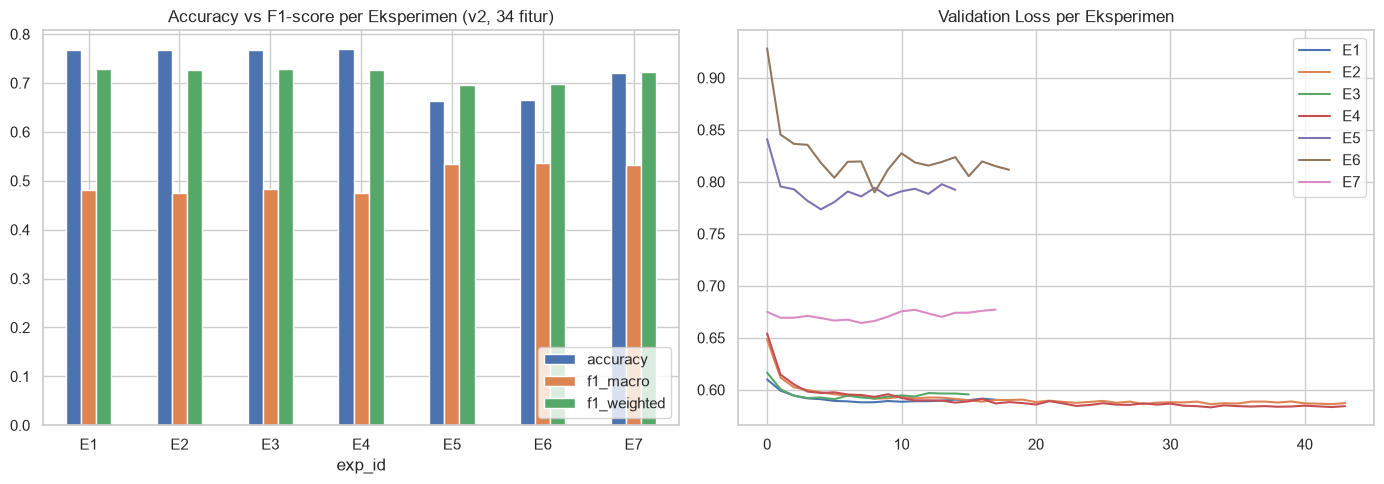

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
results_df[['accuracy', 'f1_macro', 'f1_weighted']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Accuracy vs F1-score per Eksperimen (v2, 34 fitur)')
axes[0].legend(loc='lower right')

for exp_id in EXPERIMENTS_V2:
    axes[1].plot(histories[exp_id]['val_loss'], label=exp_id)
axes[1].set_title('Validation Loss per Eksperimen')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'experiment_comparison_v2.png'), dpi=120)
plt.show()

Eksperimen terbaik (v2): E6 (ANN + Dropout + Class Weight)
F1-macro: 0.5363 | Accuracy: 0.6659
                precision    recall  f1-score   support

         Prime       0.56      0.57      0.57     31457
    Performing       0.88      0.72      0.79     91536
Non-Performing       0.17      0.45      0.25     10114

      accuracy                           0.67    133107
     macro avg       0.54      0.58      0.54    133107
  weighted avg       0.75      0.67      0.70    133107



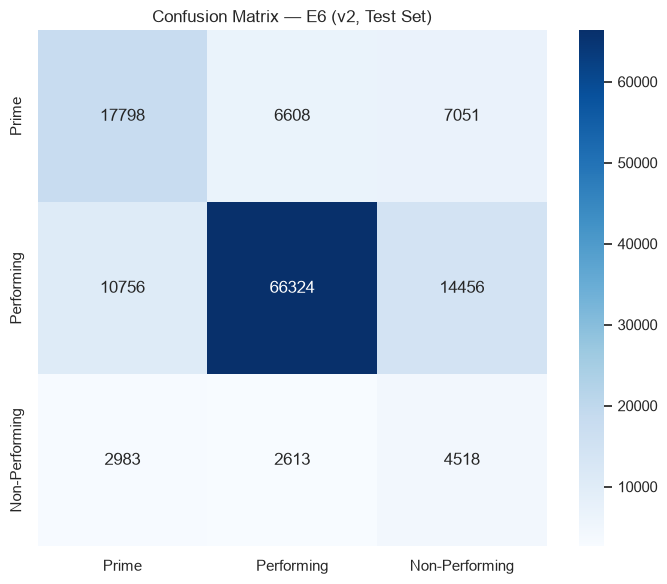

In [8]:
best_exp_id = results_df['f1_macro'].idxmax()
best_model = trained_models[best_exp_id]
best_y_pred = predictions[best_exp_id]

print(f'Eksperimen terbaik (v2): {best_exp_id} ({EXPERIMENTS_V2[best_exp_id]["description"]})')
print(f'F1-macro: {results_df.loc[best_exp_id, "f1_macro"]:.4f} | Accuracy: {results_df.loc[best_exp_id, "accuracy"]:.4f}')

print(classification_report(
    y_test, best_y_pred,
    target_names=[label_names[i] for i in sorted(label_names)],
    zero_division=0,
))

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_names[i] for i in sorted(label_names)],
            yticklabels=[label_names[i] for i in sorted(label_names)])
plt.title(f'Confusion Matrix — {best_exp_id} (v2, Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'confusion_matrix_best_model_v2.png'), dpi=120)
plt.show()

In [9]:
# ================================================
# Simpan model terbaik v2 + riwayat eksperimen
# ================================================
model_path = os.path.join(MODELS, 'best_model_v2.keras')
best_model.save(model_path)

results_df.to_csv(os.path.join(REPORTS, 'experiment_results_v2.csv'))
save_json(
    {'best_exp_id': best_exp_id, 'config': EXPERIMENTS_V2[best_exp_id]},
    'best_model_info_v2.json',
)

print(f'Model terbaik v2 disimpan di: {model_path}')
print('Hasil eksperimen v2 disimpan di: reports/experiment_results_v2.csv')

Model terbaik v2 disimpan di: d:\coding\semester6\creditScoring\models\best_model_v2.keras
Hasil eksperimen v2 disimpan di: reports/experiment_results_v2.csv
